# Feature Engineering

Analysons les colonnes, les dupliquées, variables NaN, etc.

In [20]:
import pandas as pd
import numpy as np
import re

In [ ]:
def feature_engineering(df):
    df_features = df.copy()
    
    if 'body' in df_features.columns:
        df_features['body'] = df_features['body'].fillna('')
    
    
    def extract_email(text):
        if pd.isna(text): return ""
        match = re.search(r'<([^>]+)>', str(text))
        if match: return match.group(1)
        return str(text)
        
    df_features['sender_clean'] = df_features['sender'].apply(extract_email)
    df_features['sender_domain'] = df_features['sender_clean'].apply(lambda x: x.split('@')[-1] if '@' in x else "unknown")
    df_features['sender_length'] = df_features['sender_clean'].apply(len)
    free_domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com']
    df_features['is_free_email'] = df_features['sender_domain'].isin(free_domains).astype(int)
    
    df_features['body_length'] = df_features['body'].apply(len)
    
    return df_features[["urls","sender_length","is_free_email","body_length","body"]]


In [27]:
df = pd.read_csv("data/SpamAssasin.csv")

On remarque un léger déséquilibre au niveau du volume de chaque class, un algorithme d'oversampling pourrait être intéressant. Mais attaquons-nous d'abord à l'aspect NLP, appliquons TF-IDF pour évaluer l'importance d'un mot dans le dataset.

Note: On oublie pas de faire le train_test_split avant pour éviter les data leakages

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["label"]), df['label'], test_size=0.2, random_state=42)

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_enriched = feature_engineering(X_train)

X_train_num = X_train_enriched[['sender_length', 'is_free_email']].values

# Max 5000 colonnes, le mot doit apparaître dans 5 lignes minimum
tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train_enriched['body'])

X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_num)])

<Axes: >

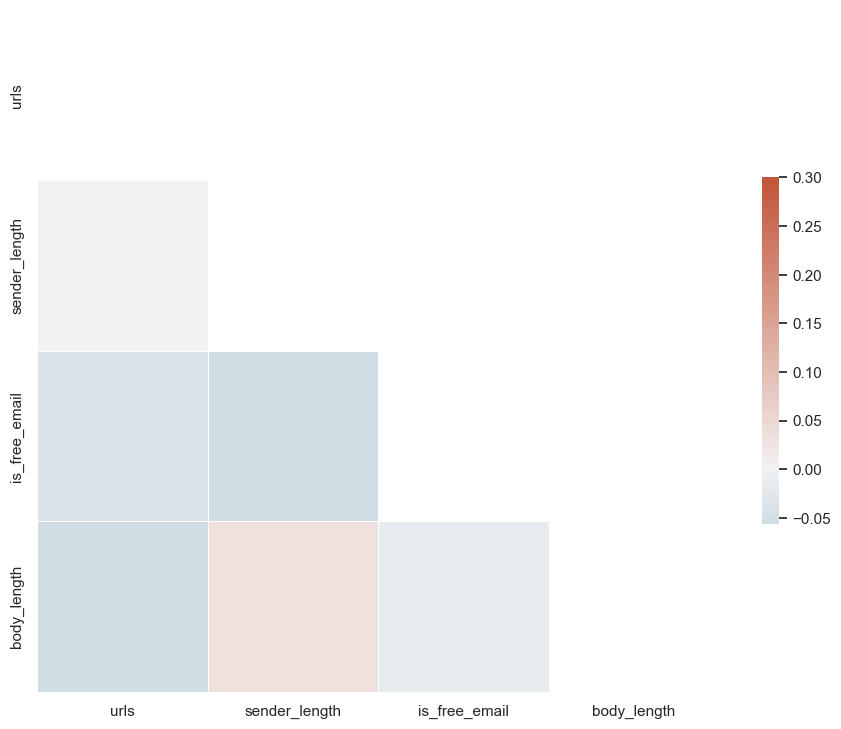

In [34]:
from string import ascii_letters
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Compute the correlation matrix (got this code from the official seaborn website)
corr = X_train_enriched.drop(columns=["body"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Pas de forte corrélation dans les nouvelles features créées.

In [ ]:
# Préparation du test set avec exactement les mêmes transformations que le train
X_test_enriched = feature_engineering(X_test)

X_test_num = X_test_enriched[['sender_length', 'is_free_email']].values

# Attention: fit_transform sur train, transform sur test seulement
X_test_tfidf = tfidf.transform(X_test_enriched['body'])

X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_num)])


On se retrouve avec 5000 colonnes (initialement 163224 colonnes sans les limites), c'est énorme. Pour éviter le surapprentissage, il faut réduire le nombre de colonne (réduire la dimension), on peut opter pour un PCA mais cela nous fait perdre en clarté au niveau du fonctionnement du modèle, si on cherche à expliquer pourquoi ça marche plus tard, on ne pourra à cause de PCA. On va donc opter pour des régulatisations L1 ou L2.

In [ ]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=100,
    reg_alpha=10,
    reg_lambda=1,
    max_depth=6,
    scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1]
)

# Exemple CatBoost
from catboost import CatBoostClassifier
model_catboost = CatBoostClassifier(
    iterations=100,
    l2_leaf_reg=5,
    depth=6
)

In [37]:
# SMOTE

from imblearn.over_sampling import SMOTE

ratio = (y_train.value_counts()[1] * 1.05)/y_train.value_counts()[0]
print(ratio)
sm = SMOTE(sampling_strategy=ratio)
X_train_res, y_train_res = sm.fit_resample(X_train_final, y_train)

print(f"Avant SMOTE : {y_train.value_counts()}")
print(f"Après SMOTE : {y_train_res.value_counts()}")

0.4485718673218673
Avant SMOTE : label
0    3256
1    1391
Name: count, dtype: int64
Après SMOTE : label
0    3256
1    1460
Name: count, dtype: int64


Le dataset est suffisamment équilibré, faire de l'undersampling n'est pas nécessaire, même l'oversampling n'était pas nécessaire dans notre situation.

In [38]:
# Prédiction!

# XGB sans SMOTE
model_xgb.fit(X_train_final, y_train)
y_pred_xgb = model_xgb.predict(X_test_final)

# XGB avec SMOTE
model_xgb.fit(X_train_res, y_train_res)
y_pred_xgb_SMOTE = model_xgb.predict(X_test_final)

# Catboost sans SMOTE
model_catboost.fit(X_train_final, y_train)
y_pred_cat = model_catboost.predict(X_test_final.toarray())

0:	learn: 0.6611642	total: 154ms	remaining: 15.2s
1:	learn: 0.6366012	total: 294ms	remaining: 14.4s
2:	learn: 0.6083098	total: 452ms	remaining: 14.6s
3:	learn: 0.5784392	total: 584ms	remaining: 14s
4:	learn: 0.5541550	total: 729ms	remaining: 13.8s
5:	learn: 0.5299410	total: 860ms	remaining: 13.5s
6:	learn: 0.5076549	total: 1.01s	remaining: 13.4s
7:	learn: 0.4867523	total: 1.15s	remaining: 13.2s
8:	learn: 0.4669927	total: 1.28s	remaining: 13s
9:	learn: 0.4529794	total: 1.4s	remaining: 12.6s
10:	learn: 0.4402099	total: 1.51s	remaining: 12.3s
11:	learn: 0.4259426	total: 1.64s	remaining: 12s
12:	learn: 0.4160041	total: 1.75s	remaining: 11.7s
13:	learn: 0.4032023	total: 1.87s	remaining: 11.5s
14:	learn: 0.3916267	total: 1.99s	remaining: 11.3s
15:	learn: 0.3820210	total: 2.1s	remaining: 11s
16:	learn: 0.3721606	total: 2.21s	remaining: 10.8s
17:	learn: 0.3617615	total: 2.32s	remaining: 10.6s
18:	learn: 0.3520324	total: 2.44s	remaining: 10.4s
19:	learn: 0.3442191	total: 2.56s	remaining: 10.3s


In [39]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def afficher_stats(y_true, y_pred, nom_modele):
    print(nom_modele)
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("\nRapport détaillé :")
    print(classification_report(y_true, y_pred))
    print("\nMatrice de confusion :")
    print(confusion_matrix(y_true, y_pred))
    print("")

# Affichage
afficher_stats(y_test, y_pred_xgb, "XGBoost")
afficher_stats(y_test, y_pred_xgb_SMOTE, "XGBoost (avec SMOTE)")
afficher_stats(y_test, y_pred_cat, "CatBoost")

XGBoost
Accuracy: 0.9707

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       835
           1       0.94      0.96      0.95       327

    accuracy                           0.97      1162
   macro avg       0.96      0.97      0.96      1162
weighted avg       0.97      0.97      0.97      1162


Matrice de confusion :
[[815  20]
 [ 14 313]]

XGBoost (avec SMOTE)
Accuracy: 0.9656

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       835
           1       0.93      0.95      0.94       327

    accuracy                           0.97      1162
   macro avg       0.95      0.96      0.96      1162
weighted avg       0.97      0.97      0.97      1162


Matrice de confusion :
[[811  24]
 [ 16 311]]

CatBoost
Accuracy: 0.9544

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.95      0.98      0.97   

XGBoost gagne, SMOTE n'a eu aucun impact important sur le modèle final car le dataset était suffisamment équilibré.

Pour aller plus loin, on peut faire du tuning des hyperparamètres, mais on considère que la précision est satisfaisante actuellement.

Maintenant on enregistre les modèles (TF-IDF + XGBoost) pour les utiliser autre part

In [41]:
import joblib

joblib.dump(tfidf, "models/tfidf.joblib")
joblib.dump(model_xgb, "models/xgb_model.joblib")

['models/xgb_model.joblib']

Features les plus importantes


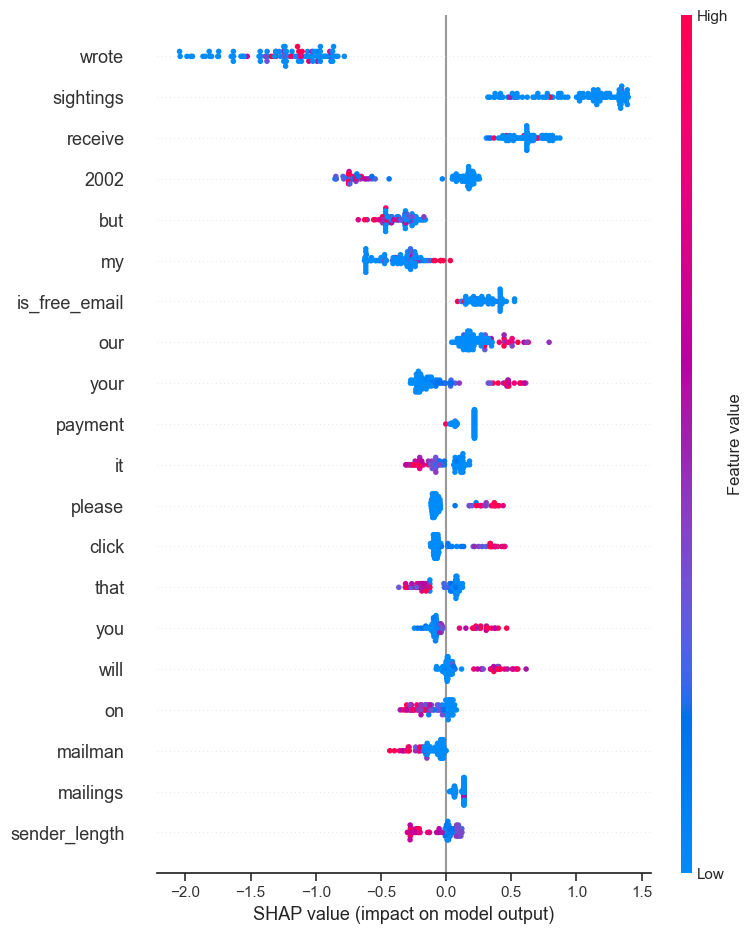

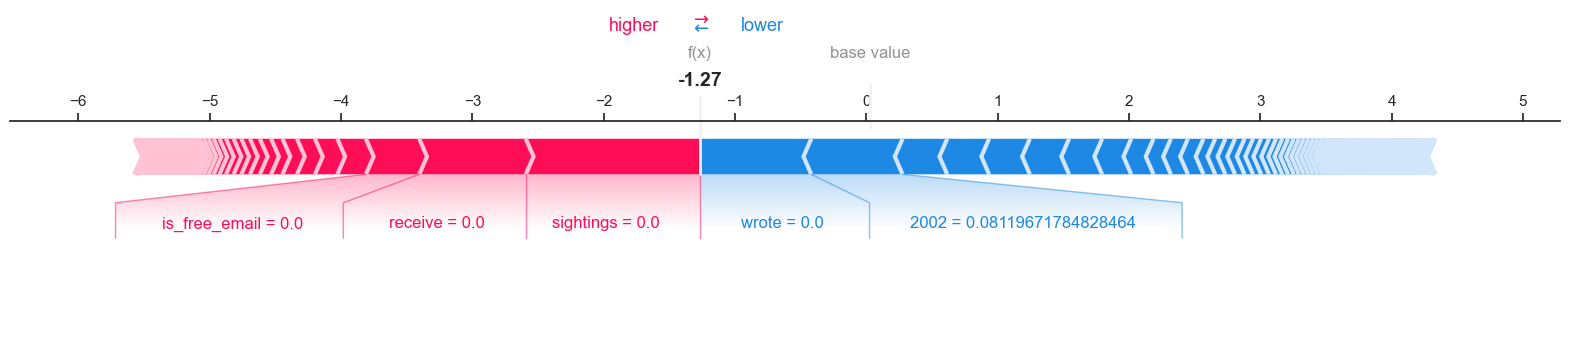

In [42]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model_xgb)

X_test_sample = X_test_final[:100].toarray()
feature_names = list(tfidf.get_feature_names_out()) + ['sender_length', 'is_free_email']

shap_values = explainer.shap_values(X_test_sample)

print("Features les plus importantes")
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names)

# Exemple sur une prédiction
index_email = 45
shap.initjs()
shap.force_plot(
    explainer.expected_value, 
    shap_values[index_email,:], 
    X_test_sample[index_email,:], 
    feature_names=feature_names,
    matplotlib=True
)

En regardant ces valeurs de Shapley, on comprend mieux la logique du modèle XGBoost.

On remarque donc que des termes comme "write" diminue fortement la probabilité de fraude. A l'inverse, des mots qui relèvent du spam comme "click", ou l'usage intensif de pronoms comme "you" ou "your" augmente le risque. La raisonnement derrière est donc logique.

Concernant le deuxième graphe (force plot), on remarque que le mot 2002 a un impact surprenament important sur le modèle.

En bref, grâce à cet outil, on comprend mieux sur quoi se base le modèle pour déterminer si un mail est un spam ou non.